# Map recurring distant location mismatches

This notebook maps coordinate cases already classified as `distant_location_conflict` in the existing review outputs. Point size represents the number of operation records at a coordinate. Colors represent the directed mismatch pair, from the reported county to the coordinate-derived county.

The map is an exploratory diagnostic. Spatial recurrence does not establish whether the reported label or coordinate is correct.

In [15]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D

data_dir = Path('/Users/oliviakuang/Documents/GitHub/Cloudseeding2')
check_dir = data_dir / 'check'

font_path = Path('/opt/X11/share/system_fonts/Hiragino Sans GB.ttc')
if font_path.exists():
    font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

In [16]:
cross_city = pd.read_csv(check_dir / 'cross_city_location_review.csv')
cross_county = pd.read_csv(check_dir / 'cross_county_same_city_review.csv')

keep = [
    'lon', 'lat', 'records', 'first_date', 'last_date',
    'reported_city', 'reported_county',
    'coordinate_city', 'coordinate_county', 'coordinate_town',
    'tools', 'review_status',
]
distant = pd.concat(
    [
        cross_city.loc[cross_city['review_status'].eq('distant_location_conflict'), keep],
        cross_county.loc[cross_county['review_status'].eq('distant_location_conflict'), keep],
    ],
    ignore_index=True,
)

def clean_label(value):
    return '' if pd.isna(value) else str(value).strip()

distant['mismatch_pair'] = (
    distant['reported_city'].map(clean_label) + '–'
    + distant['reported_county'].map(clean_label) + ' → '
    + distant['coordinate_city'].map(clean_label) + '–'
    + distant['coordinate_county'].map(clean_label)
)
distant['reported_to_coordinate_county'] = (
    distant['reported_county'].map(clean_label) + ' → '
    + distant['coordinate_county'].map(clean_label)
)
distant_points = gpd.GeoDataFrame(
    distant,
    geometry=gpd.points_from_xy(distant['lon'], distant['lat']),
    crs='EPSG:4326',
)

print(f'Distant coordinate cases: {len(distant_points):,}')
print(f'Associated operation records: {distant_points["records"].sum():,}')
print(f'Directed mismatch pairs: {distant_points["mismatch_pair"].nunique():,}')

Distant coordinate cases: 25
Associated operation records: 182
Directed mismatch pairs: 16


## Coordinate-level grouped table

The table retains all 25 distant coordinate cases. Rows are grouped by the directed reported-to-coordinate-derived location pair and ordered by the pair's total number of operations. Repeated pair labels are visually suppressed only for readability; the underlying data remain unchanged.

In [17]:
location_table = distant.copy()
location_table['pair_total_records'] = (
    location_table.groupby('mismatch_pair')['records'].transform('sum')
)
location_table['coordinate'] = location_table.apply(
    lambda row: f"({row['lon']:.5f}, {row['lat']:.5f})",
    axis=1,
)
location_table['coordinate_location'] = (
    location_table['coordinate_city'].map(clean_label) + '–'
    + location_table['coordinate_county'].map(clean_label) + '–'
    + location_table['coordinate_town'].map(clean_label)
)
location_table['date_span'] = (
    location_table['first_date'].astype(str) + ' to '
    + location_table['last_date'].astype(str)
)
location_table = location_table.sort_values(
    ['pair_total_records', 'mismatch_pair', 'records', 'coordinate_location'],
    ascending=[False, True, False, True],
).reset_index(drop=True)

table_for_display = location_table[[
    'mismatch_pair', 'pair_total_records', 'coordinate_location',
    'coordinate', 'records', 'date_span', 'tools',
]].copy()
table_for_display.columns = [
    'Reported → coordinate-derived', 'Pair records',
    'Coordinate-derived location', 'Coordinate',
    'Records at coordinate', 'Date span', 'Tools',
]
table_for_display['Pair records'] = (
    table_for_display['Pair records'].astype('object')
)

same_as_previous = table_for_display[
    'Reported → coordinate-derived'
].eq(
    table_for_display['Reported → coordinate-derived'].shift()
)
table_for_display.loc[
    same_as_previous,
    ['Reported → coordinate-derived', 'Pair records'],
] = ''

styled_location_table = (
    table_for_display.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
    ])
)

try:
    display(styled_location_table)
except NameError:
    print(table_for_display.to_string(index=False))

# Quantify how concentrated the distant-conflict records are.
total_distant_records = int(distant['records'].sum())
yuehu_distant_records = int(
    distant.loc[
        distant['reported_county'].map(clean_label).eq('月湖区'),
        'records',
    ].sum()
)
lean_xiajiang_records = int(
    distant.loc[
        distant['reported_county'].map(clean_label).isin(['乐安县', '乐安'])
        & distant['coordinate_county'].map(clean_label).eq('峡江县'),
        'records',
    ].sum()
)

concentration_summary = pd.DataFrame(
    {
        'Pattern': [
            'Reported 月湖区 → other coordinate-derived counties',
            'Reported 乐安县/乐安 → coordinate-derived 峡江县',
            'Two patterns combined',
        ],
        'Distant-mismatch records': [
            yuehu_distant_records,
            lean_xiajiang_records,
            yuehu_distant_records + lean_xiajiang_records,
        ],
    }
)
concentration_summary['Share of all distant-mismatch records'] = (
    concentration_summary['Distant-mismatch records']
    / total_distant_records
)

styled_concentration_summary = (
    concentration_summary.style
    .hide(axis='index')
    .format({'Share of all distant-mismatch records': '{:.1%}'})
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
    ])
)

try:
    display(styled_concentration_summary)
except NameError:
    printable_summary = concentration_summary.copy()
    printable_summary['Share of all distant-mismatch records'] = (
        printable_summary['Share of all distant-mismatch records']
        .map('{:.1%}'.format)
    )
    print('\nConcentration of distant-mismatch records')
    print(printable_summary.to_string(index=False))

Reported → coordinate-derived,Pair records,Coordinate-derived location,Coordinate,Records at coordinate,Date span,Tools
鹰潭市–月湖区 → 鹰潭市–贵溪市,99,鹰潭市–贵溪市–龙虎山镇,"(116.96300, 28.09800)",45,2021-01-25 to 2022-10-09,烟炉
,,鹰潭市–贵溪市–塔桥园艺场,"(117.06800, 28.44900)",16,2023-01-22 to 2025-09-12,火箭弹
,,鹰潭市–贵溪市–龙虎山镇,"(116.95900, 28.09800)",12,2022-10-27 to 2025-07-18,烟炉
,,鹰潭市–贵溪市–上清镇,"(117.03300, 27.98700)",8,2024-07-28 to 2025-01-31,烟炉
,,鹰潭市–贵溪市–塔桥园艺场,"(117.08000, 28.44900)",8,2022-01-05 to 2022-08-04,火箭弹
,,鹰潭市–贵溪市–耳口乡,"(117.16000, 27.99200)",5,2024-08-04 to 2025-07-08,烟炉
,,鹰潭市–贵溪市–龙虎山镇,"(116.94200, 28.06900)",3,2022-08-10 to 2024-08-06,火箭弹
,,鹰潭市–贵溪市–上清镇,"(117.04700, 27.98700)",1,2021-06-18 to 2021-06-18,火箭弹
,,鹰潭市–贵溪市–上清镇,"(117.07400, 27.99400)",1,2025-08-27 to 2025-08-27,火箭弹
抚州市–乐安县 → 吉安市–峡江县,49,吉安市–峡江县–马埠镇,"(115.41800, 27.56800)",49,2021-02-09 to 2025-10-13,烟炉


Pattern,Distant-mismatch records,Share of all distant-mismatch records
Reported 月湖区 → other coordinate-derived counties,106,58.2%
Reported 乐安县/乐安 → coordinate-derived 峡江县,49,26.9%
Two patterns combined,155,85.2%


## Potential selection from removing geographic mismatches

The distant-conflict map is based only on mismatched coordinates. To assess selective deletion, this section returns to the complete `cleaned_operation.csv` and compares records reported as `月湖区` with records reported as `乐安县` or `乐安`. The calculations describe how exclusion rules change the sample; they do not determine whether the reported label or coordinate is correct.

In [18]:
cleaned = pd.read_csv(data_dir / "intermediate/cleaned_operation.csv")
reported_county_clean = cleaned["county_o"].map(clean_label)

yuehu = cleaned.loc[reported_county_clean.eq("月湖区")].copy()
lean = cleaned.loc[reported_county_clean.isin(["乐安县", "乐安"])].copy()

yuehu_total = len(yuehu)
yuehu_to_guixi = int(yuehu["county"].map(clean_label).eq("贵溪市").sum())
yuehu_to_yiyang = int(yuehu["county"].map(clean_label).eq("弋阳县").sum())
yuehu_spatial_matches = int(yuehu["county"].map(clean_label).eq("月湖区").sum())
yuehu_distant = yuehu_distant_records
yuehu_near_boundary = yuehu_total - yuehu_distant - yuehu_spatial_matches

lean_total = len(lean)
lean_spatial_matches = int(lean["county"].map(clean_label).eq("乐安县").sum())
lean_to_xiajiang = int(lean["county"].map(clean_label).eq("峡江县").sum())
lean_xiajiang_coordinates = (
    lean.loc[lean["county"].map(clean_label).eq("峡江县"), ["lon", "lat"]]
    .drop_duplicates().shape[0]
)

reported_county_comparison = pd.DataFrame([
    {
        "Reported county group": "月湖区",
        "All reported records": yuehu_total,
        "Coordinate-derived matches": yuehu_spatial_matches,
        "Near-boundary mismatches": yuehu_near_boundary,
        "Distant mismatches": yuehu_distant,
        "Share removed: distant only": yuehu_distant / yuehu_total,
        "Share removed: all geographic mismatches": (
            yuehu_total - yuehu_spatial_matches
        ) / yuehu_total,
    },
    {
        "Reported county group": "乐安县 / 乐安",
        "All reported records": lean_total,
        "Coordinate-derived matches": lean_spatial_matches,
        "Near-boundary mismatches": 0,
        "Distant mismatches": lean_to_xiajiang,
        "Share removed: distant only": lean_to_xiajiang / lean_total,
        "Share removed: all geographic mismatches": (
            lean_total - lean_spatial_matches
        ) / lean_total,
    },
])

styled_reported_county_comparison = (
    reported_county_comparison.style
    .hide(axis="index")
    .format({
        "Share removed: distant only": "{:.1%}",
        "Share removed: all geographic mismatches": "{:.1%}",
    })
    .set_properties(**{"text-align": "left"})
)
try:
    display(styled_reported_county_comparison)
except NameError:
    printable_comparison = reported_county_comparison.copy()
    for column in [
        "Share removed: distant only",
        "Share removed: all geographic mismatches",
    ]:
        printable_comparison[column] = printable_comparison[column].map("{:.1%}".format)
    print(printable_comparison.to_string(index=False))

print(
    f"月湖区: {yuehu_to_guixi} of {yuehu_total} records "
    f"({yuehu_to_guixi / yuehu_total:.1%}) are coordinate-assigned to 贵溪市; "
    f"{yuehu_to_yiyang} are assigned to 弋阳县; "
    f"{yuehu_spatial_matches} are assigned to 月湖区."
)
print(
    f"乐安县/乐安: {lean_spatial_matches} of {lean_total} records "
    f"({lean_spatial_matches / lean_total:.1%}) are coordinate-assigned to 乐安县; "
    f"{lean_to_xiajiang} ({lean_to_xiajiang / lean_total:.1%}) are assigned "
    f"to 峡江县 at {lean_xiajiang_coordinates} exact coordinate."
)

Reported county group,All reported records,Coordinate-derived matches,Near-boundary mismatches,Distant mismatches,Share removed: distant only,Share removed: all geographic mismatches
月湖区,137,0,31,106,77.4%,100.0%
乐安县 / 乐安,135,86,0,49,36.3%,36.3%


月湖区: 130 of 137 records (94.9%) are coordinate-assigned to 贵溪市; 7 are assigned to 弋阳县; 0 are assigned to 月湖区.
乐安县/乐安: 86 of 135 records (63.7%) are coordinate-assigned to 乐安县; 49 (36.3%) are assigned to 峡江县 at 1 exact coordinate.


### Interpretation

The two recurring patterns imply different selection risks:

- **Reported 月湖区 is a systematic multi-location mismatch pattern.** Of 137 reported 月湖区 records, 130 are coordinate-assigned to 贵溪市 and 7 to 弋阳县; none are coordinate-assigned to 月湖区. Removing only distant conflicts would remove 106 records (77.4%). Removing all geographic mismatches, including the 31 near-boundary cases, would remove all 137 reported 月湖区 records. This would eliminate the reported 月湖区 group and also reduce coordinate-based operations assigned to 贵溪市 and 弋阳县.
- **Reported 乐安县 is mostly spatially consistent, with one recurring site exception.** Of 135 records reported as 乐安县 or 乐安, 86 are coordinate-assigned to 乐安县. The remaining 49 are all assigned to 峡江县–马埠镇 at the single coordinate `(115.418, 27.568)`, spanning 2021–2025. Removing this pattern would therefore delete one persistent site rather than the entire reported county group.

Consequently, blanket removal of distant mismatches would be geographically and operationally selective. These records should remain in the primary coordinate-based analysis with mismatch flags, while exclusion is better treated as a sensitivity specification.

In [19]:
townships = gpd.read_file(data_dir / 'township_shapefile/xiangzhen.shp')
townships = townships.loc[
    townships['省'].eq('江西省'),
    ['市', '县', '乡', 'geometry'],
].copy()

county_boundaries = townships.dissolve(by=['市', '县']).boundary
city_boundaries = townships.dissolve(by='市').boundary
province_boundary = townships.dissolve().boundary

yingtan_towns = townships.loc[townships['市'].astype(str).str.contains('鹰潭', na=False)].copy()
yingtan_counties = yingtan_towns.dissolve(by=['市', '县']).reset_index()

/Users/oliviakuang/Documents/GitHub/Cloudseeding2/check/distant_mismatch_recurrence_map.png


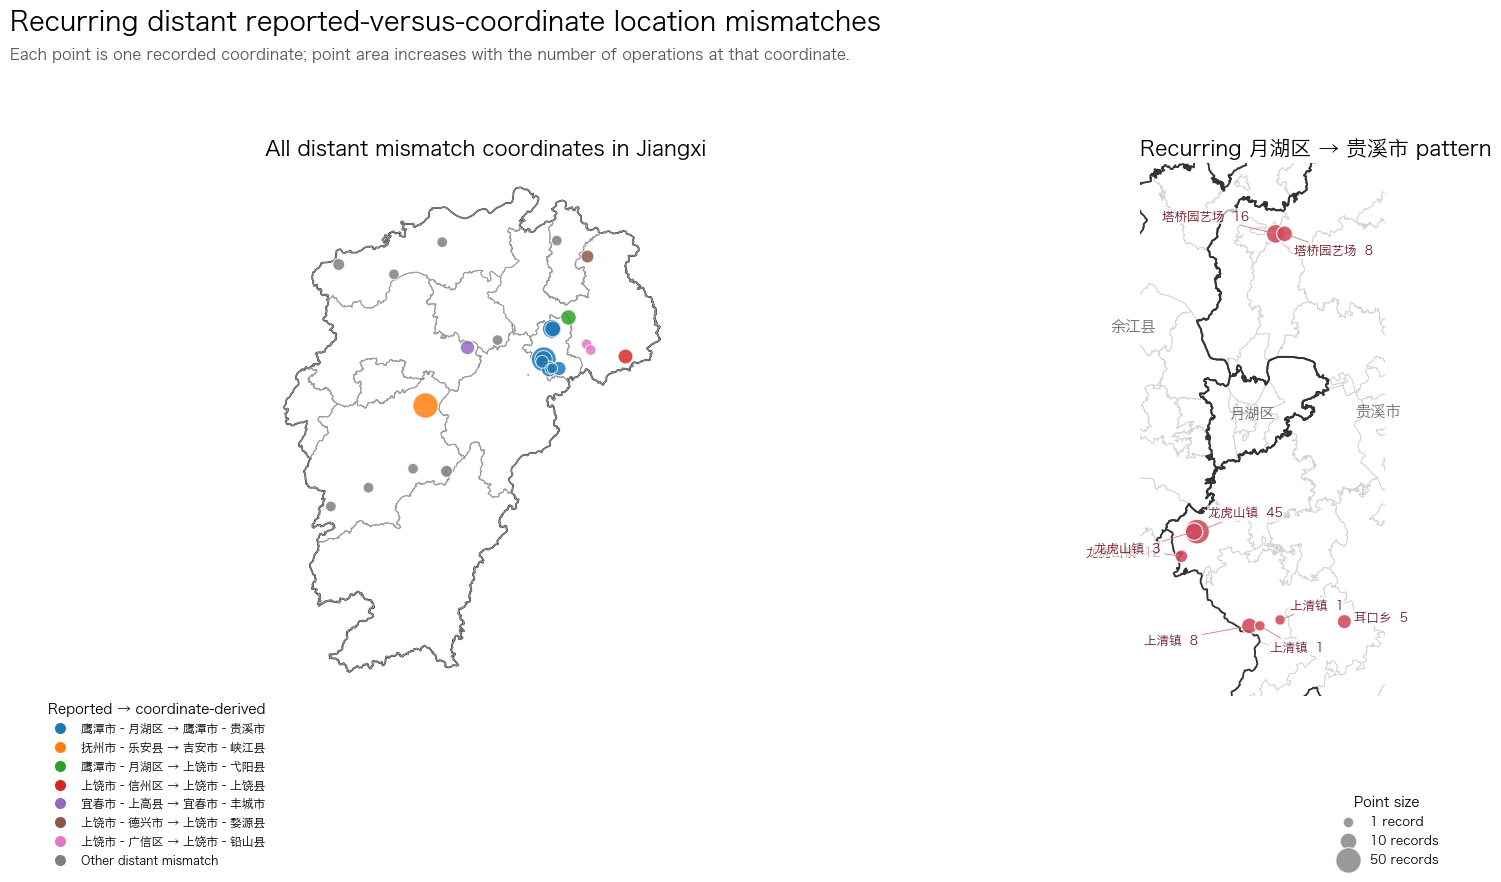

In [20]:
pair_counts = (
    distant_points.groupby('mismatch_pair')['records']
    .sum()
    .sort_values(ascending=False)
)
top_pairs = pair_counts.index[:7].tolist()
distant_points['map_pair'] = distant_points['mismatch_pair'].where(
    distant_points['mismatch_pair'].isin(top_pairs),
    'Other distant mismatch',
)

palette = list(plt.get_cmap('tab10').colors)
pair_order = top_pairs + (['Other distant mismatch'] if (distant_points['map_pair'] == 'Other distant mismatch').any() else [])
colors = {pair: palette[i % len(palette)] for i, pair in enumerate(pair_order)}

def marker_size(records):
    return 32 + 27 * (records ** 0.62)

fig, (ax_all, ax_focus) = plt.subplots(
    1, 2, figsize=(18, 9), gridspec_kw={'width_ratios': [1.05, 1]}
)

province_boundary.plot(ax=ax_all, color='#222222', linewidth=1.2)
city_boundaries.plot(ax=ax_all, color='#9a9a9a', linewidth=0.65)
for pair in pair_order:
    group = distant_points.loc[distant_points['map_pair'].eq(pair)]
    group.plot(
        ax=ax_all, color=colors[pair], edgecolor='white', linewidth=0.7,
        markersize=group['records'].map(marker_size), alpha=0.84, zorder=3,
    )
ax_all.set_title('All distant mismatch coordinates in Jiangxi', fontsize=15, loc='left')
ax_all.set_axis_off()

yingtan_towns.boundary.plot(ax=ax_focus, color='#d2d2d2', linewidth=0.55)
yingtan_counties.boundary.plot(ax=ax_focus, color='#333333', linewidth=1.3)
monthly_guixi = distant_points.loc[
    distant_points['reported_county'].astype(str).str.contains('月湖', na=False)
    & distant_points['coordinate_county'].astype(str).str.contains('贵溪', na=False)
].copy()
monthly_guixi.plot(
    ax=ax_focus, color='#d1495b', edgecolor='white', linewidth=0.9,
    markersize=monthly_guixi['records'].map(marker_size), alpha=0.88, zorder=4,
)
label_offsets = {
    (116.963, 28.098): (8, 11),
    (116.959, 28.098): (-78, -18),
    (116.942, 28.069): (-63, 3),
    (117.033, 27.987): (-76, -13),
    (117.047, 27.987): (7, -18),
    (117.074, 27.994): (7, 8),
    (117.160, 27.992): (7, 0),
    (117.068, 28.449): (-82, 10),
    (117.080, 28.449): (7, -15),
}
for row in monthly_guixi.itertuples():
    offset = label_offsets.get((round(row.lon, 3), round(row.lat, 3)), (5, 5))
    ax_focus.annotate(
        f'{row.coordinate_town}  {row.records}',
        (row.lon, row.lat), xytext=offset, textcoords='offset points',
        fontsize=9, color='#6f1723', zorder=5,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.67, 'pad': 1.1},
        arrowprops={'arrowstyle': '-', 'color': '#c97983', 'linewidth': 0.6},
    )
for row in yingtan_counties.itertuples():
    center = row.geometry.representative_point()
    ax_focus.text(
        center.x, center.y, str(row.县), ha='center', va='center',
        fontsize=11, color='#555555', alpha=0.85, zorder=2,
    )
if len(monthly_guixi):
    xmin, ymin, xmax, ymax = monthly_guixi.total_bounds
    xpad = max((xmax - xmin) * 0.20, 0.055)
    ypad = max((ymax - ymin) * 0.18, 0.045)
    ax_focus.set_xlim(xmin - xpad, xmax + xpad)
    ax_focus.set_ylim(ymin - ypad, ymax + ypad)
ax_focus.set_title('Recurring 月湖区 → 贵溪市 pattern', fontsize=15, loc='left')
ax_focus.set_axis_off()

pair_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor=colors[pair],
           markeredgecolor='white', markersize=9, label=pair)
    for pair in pair_order
]
fig.legend(
    handles=pair_handles, title='Reported → coordinate-derived',
    loc='lower left', bbox_to_anchor=(0.055, 0.015),
    frameon=False, fontsize=8.5,
)
size_values = [1, 10, 50]
size_handles = [
    plt.scatter([], [], s=marker_size(value), color='#777777', alpha=0.75,
                edgecolor='white', label=f'{value} record' + ('s' if value != 1 else ''))
    for value in size_values
]
fig.legend(
    handles=size_handles, title='Point size', loc='lower left',
    bbox_to_anchor=(0.77, 0.015), frameon=False, fontsize=9,
)
fig.suptitle('Recurring distant reported-versus-coordinate location mismatches', fontsize=19, x=0.04, ha='left')
fig.text(
    0.04, 0.925,
    'Each point is one recorded coordinate; point area increases with the number of operations at that coordinate.',
    fontsize=11, color='#555555',
)
plt.tight_layout(rect=[0.02, 0.20, 1, 0.90])
output_path = check_dir / 'distant_mismatch_recurrence_map.png'
fig.savefig(output_path, dpi=220, bbox_inches='tight', facecolor='white')
print(output_path)
plt.show()

## Reading the map

Large points show coordinates reused in many operations. Several nearby points of the same color show a recurring regional pattern rather than one duplicated coordinate. The focused map labels the coordinate-derived township and record count for each `月湖区 → 贵溪市` coordinate.